# **EDA Notebook**



---
## 0. Setup Environment

### 0.a Install Mandatory Packages

> Do not modify this code before running it

In [116]:
# Do not modify this code

import os
import sys
from pathlib import Path

COURSE = "36106"
ASSIGNMENT = "AT3"
DATA = "data"

asgmt_path = f"{COURSE}/assignment/{ASSIGNMENT}"
root_path = "./"

#print("###### Install required Python packages ######")
! pip install -q -r https://raw.githubusercontent.com/aso-uts/labs_datasets/main/36106-mlaa/requirements.txt

if os.getenv("COLAB_RELEASE_TAG"):

    from google.colab import drive
    from pathlib import Path

    #print("\n###### Connect to personal Google Drive ######")
    gdrive_path = "/content/gdrive"
    drive.mount(gdrive_path)
    root_path = f"{gdrive_path}/MyDrive/"

print("\n###### Setting up folders ######")
folder_path = Path(f"{root_path}/{asgmt_path}/") / DATA
folder_path.mkdir(parents=True, exist_ok=True)
print(f"\nYou can now save your data files in: {folder_path}")

if os.getenv("COLAB_RELEASE_TAG"):
    %cd {folder_path}

from IPython.display import display, HTML

def print_tile(key, value, size="h1"):
  return display(HTML(f"""<p style="color:grey">{key}</p><{size} font-size: 3em>{value}</{size}>"""))

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).

###### Setting up folders ######

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data
/content/gdrive/MyDrive/36106/assignment/AT3/data


### 0.b Disable Warnings Messages

> Do not modify this code before running it

In [117]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 0.d Import Packages

In [118]:
# <Student to fill this section>
import pandas as pd
import altair as alt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

---
## A. Project Description


In [119]:
# <Student to fill this section>
group_name = "24"
student_name = "Sahaj Gupta"
student_id = "25585973"

In [120]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [121]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [122]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Data Understanding

### B.1   Load Dataset

In [123]:
# Do not modify this code
try:
  df = pd.read_csv(folder_path / "customer_details.csv")
except Exception as e:
  print(e)

### B.2 Explore Dataset

> You can add more cells in this section

In [124]:
# <Student to fill this section>
# First five rows of dataset
df.head()

,Unnamed: 0,customer_id,full_name,gender,dob,age,is_young_adult,is_senior,birth_country,passport_number,...,city,postcode,state_abbr,address,cc_number,cc_expiry,cc_security_code,company_name,company_suffix,user_agent
0,0,9acb3a1e-a040-4280-887b-ef33381c7a16,Alexa Chung,Female,1974-10-10,50,No,No,AU,131053534,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,45360147-4c3e-4f3d-8d8d-a6aa8f0bb47f,Mrs. Megan,Female,1981-09-27,43,No,No,AU,379521345,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,8345bdc5-75fd-41da-8ce5-7828e5a27666,Amy Rose,Female,1989-09-16,35,No,No,PH,794022868,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,0ec226b1-22e6-4b98-919f-c1c0cd183ea7,Ryan Peterson,Male,2001-02-03,24,Yes,No,AU,M21113240,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,f588a5e1-7b36-4db2-af9a-2c14e041fccb,Shelby Meyer,Female,1977-02-11,48,No,No,AU,956682468,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [125]:
#Dimensions of dataset
df.shape

(11688, 36)

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11688 entries, 0 to 11687
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         11688 non-null  int64  
 1   customer_id        11688 non-null  object 
 2   full_name          11688 non-null  object 
 3   gender             11688 non-null  object 
 4   dob                11688 non-null  object 
 5   age                11688 non-null  int64  
 6   is_young_adult     11688 non-null  object 
 7   is_senior          11688 non-null  object 
 8   birth_country      11688 non-null  object 
 9   passport_number    11688 non-null  object 
 10  passport_expiry    11688 non-null  object 
 11  phone_number       11688 non-null  object 
 12  email              11688 non-null  object 
 13  marital_status     11688 non-null  object 
 14  has_children       11688 non-null  object 
 15  number_dependents  11688 non-null  int64  
 16  Gender             168

In [127]:
#Descriptive statistics of dataset
df.describe()

,Unnamed: 0,age,number_dependents,building_number,postcode,cc_number,cc_security_code
count,11688.000000,11688.000000,11688.000000,1688.000000,1688.000000,1.688000e+03,1688.000000
mean,5843.500000,47.828970,0.694644,171.125000,3102.980450,4.149108e+17,884.476303
std,3374.179308,17.807161,1.168934,270.512982,1731.195095,1.300788e+18,1509.431934
min,0.000000,18.000000,0.000000,0.000000,202.000000,6.040156e+10,1.000000
25%,2921.750000,33.000000,0.000000,6.000000,2581.750000,1.800107e+14,277.000000
50%,5843.500000,47.000000,0.000000,39.000000,2689.000000,3.512907e+15,562.000000
75%,8765.250000,61.000000,1.000000,189.000000,2962.000000,4.663844e+15,821.000000
max,11687.000000,92.000000,9.000000,998.000000,9988.000000,4.989705e+18,9960.000000


In [128]:
# <Student to fill this section>
dataset_insights = """
1. The dataset consists of 11,688 records and 36 features. It can be observed that almost half of the customer details such as full_name, gender, dob, passport details
are fully populated for all rows whereas details like address, company name and credit card number are populated for only ~1,688 rows (~14%) indicating almost 86% of the
dataset lacks this additional information.
2. Age: The values range from 18 to 92 with mean = 47.8 indicating balanced spread with a tilt toward middle-aged and senior customers.
Age segmentation (e.g., <30, 30–60, 60+) may be insightful.
3. number_dependents: Mean = ~0.7 and Median = 0 which suggests that most customers have no dependents. Max value = 9 indicates a possible outlier.
"""

In [129]:
# Do not modify this code
print_tile(size="h3", key='dataset_insights', value=dataset_insights)

### B.3 Explore 'Gender'

In [130]:
df['gender'].value_counts()

,count
gender,
Male,5645
Female,5471
Unknown,572


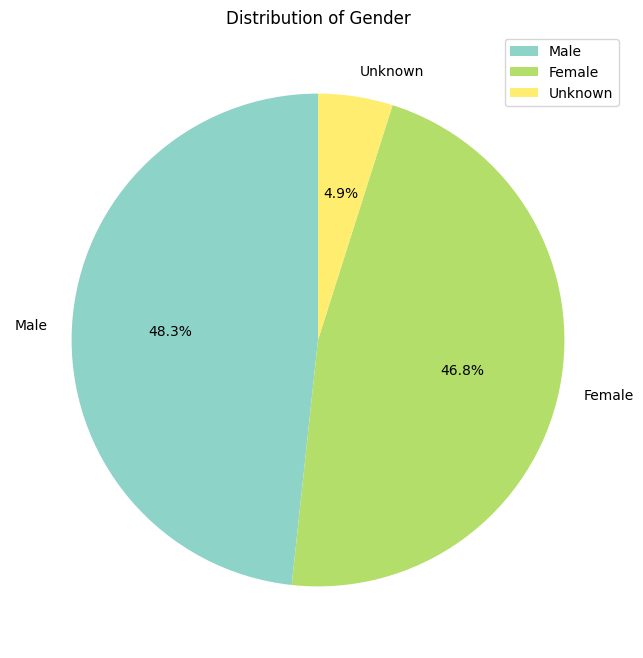

In [131]:
# <Student to fill this section>
# Distribution of Gender in the dataset

plt.figure(figsize=(15, 8))
df['gender'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Set3')
plt.title('Distribution of Gender')
plt.xlabel('')
plt.ylabel('')
plt.legend()
plt.show()

In [132]:
# <Student to fill this section>
feature1_insights = """
The dataset has a fairly even split between male and female customers. A small percentage (~5%) has unspecified or missing gender data, which may need cleaning or
imputation depending on use.
"""

In [133]:
# Do not modify this code
print_tile(size="h3", key='feature1_insights', value=feature1_insights)

### B.4 Explore Features - 'birth_country', 'marital_status', 'has_children', 'number_dependents','is_young_adult', 'is_senior'

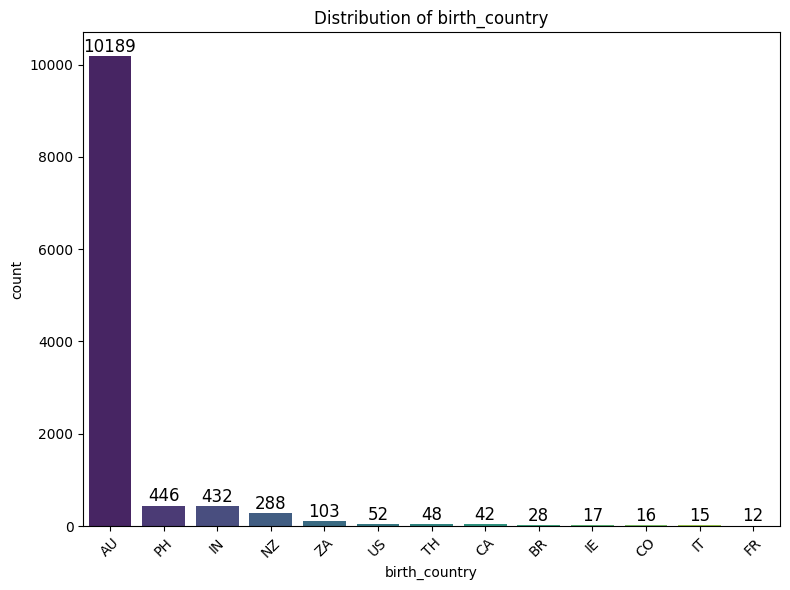

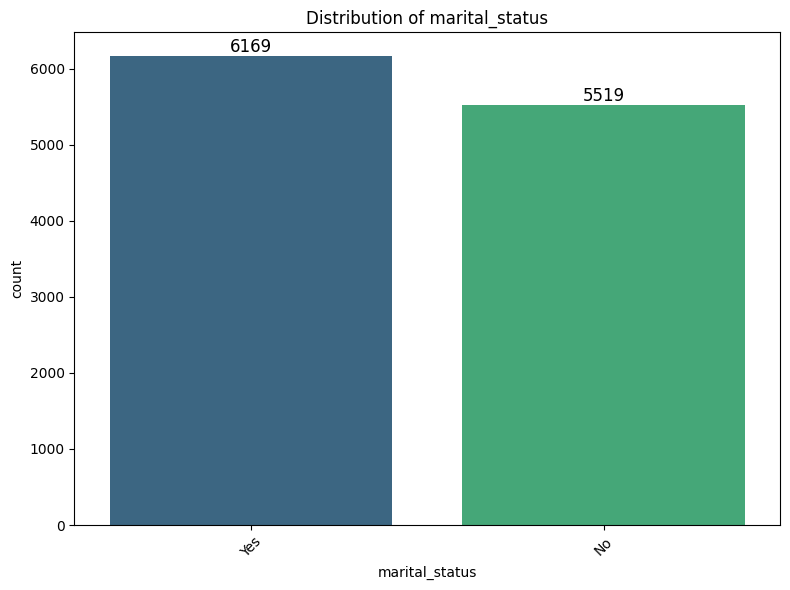

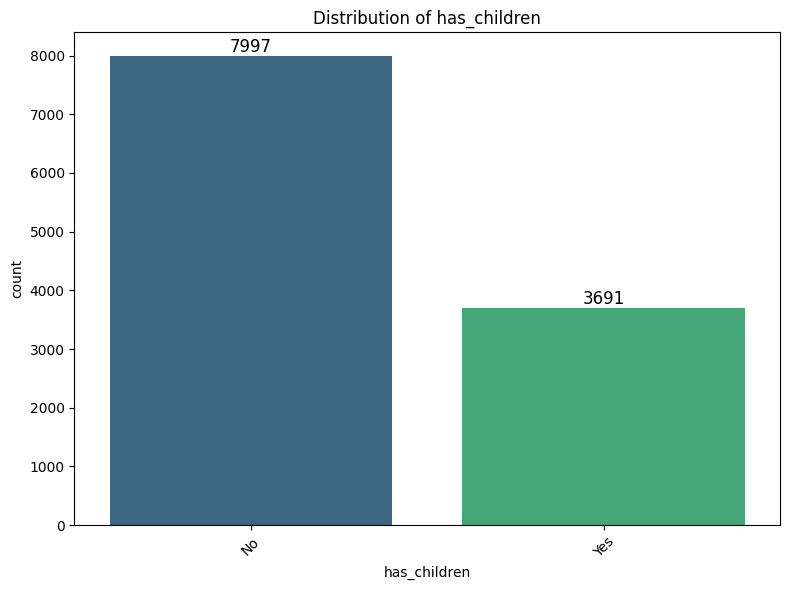

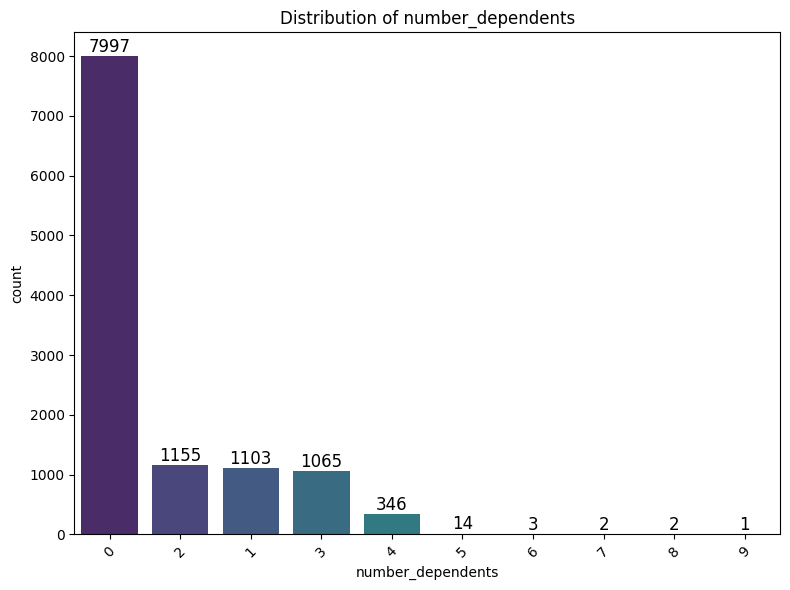

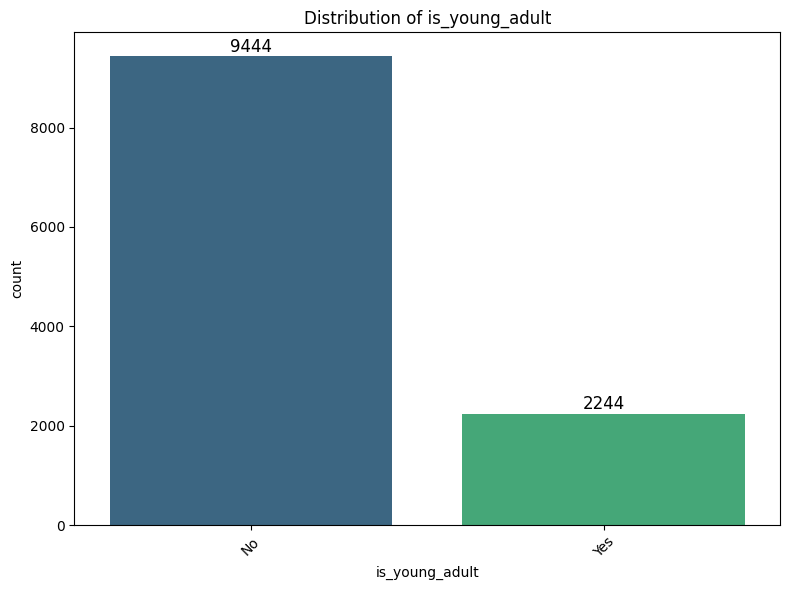

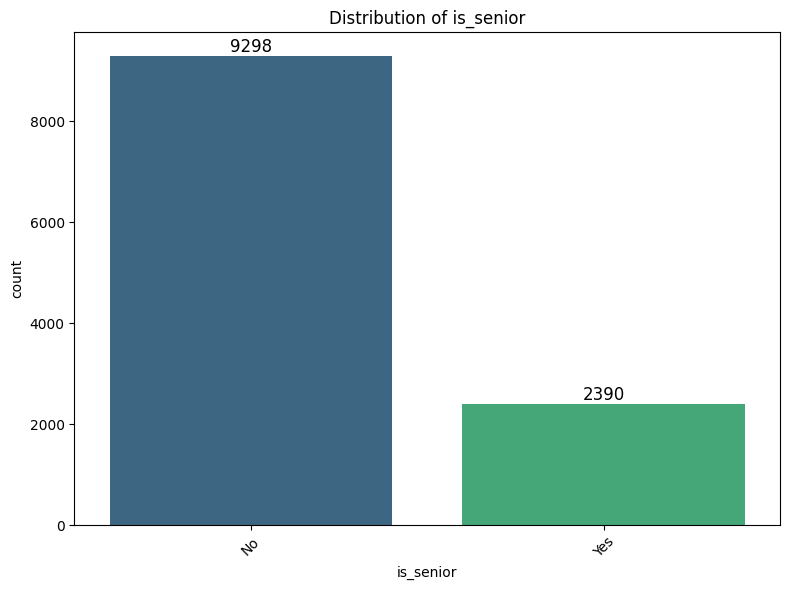

In [134]:
# <Student to fill this section>
categorical_cols = ['birth_country', 'marital_status', 'has_children', 'number_dependents','is_young_adult', 'is_senior']

for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette = "viridis")

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 3),
                    textcoords='offset points')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [135]:
# <Student to fill this section>
feature_insights = """
Birth Country: Australia clearly dominates the distribution in terms of birth country with other countries like Philippines and India having much smaller counts.
This shows that the dataset is highly skewed toward customers from the Australia likely reflecting a local customer base and may limit global generalizability unless
filtered or stratified.

Marital Status: Nearly a 50–50 split, with a slight majority being married. This feature might be valuable for analyzing household patterns or financial needs.

Has Children: Around 68% of the customers have no children which may lead to predictive models prioritizing single or non-family customers and not learning enough from
the smaller group to accurately capture their behavior.

Number of Dependents: Majority customers have 0 dependents (7,997) with 1–3 dependents forming a smaller secondary group. A few entries with up to 9 dependents suggest
potential outliers. This indicates that the distribution is highly skewed with most customers having no dependents. Binning can be considered during modeling phase to
improve stability and enhance model interpretability.

is_young_adult: Approximately 19% of customers are classified as young adults which is a small but distinct segment for marketing or behavioral differentiation.

is_senior: Approximately 20% of the customer base consists of senior individuals, highlighting a valuable segment for creating age-specific products and services and
tailored marketing strategies.
"""

In [136]:
# Do not modify this code
print_tile(size="h3", key='feature_insights', value=feature_insights)

### B.5 Explore 'Age'

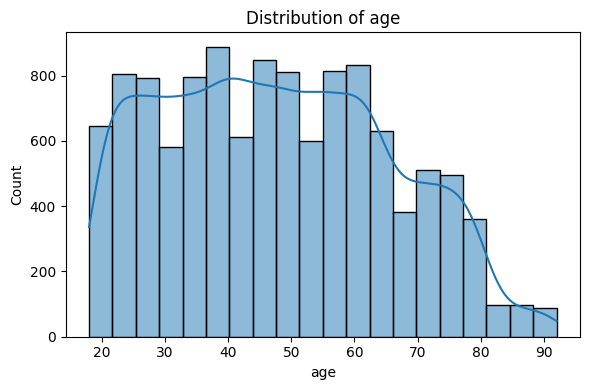

In [137]:
# <Student to fill this section>
plt.figure(figsize=(6, 4))
sns.histplot(df['age'], kde=True, bins=20)
plt.title(f'Distribution of age')
plt.tight_layout()
plt.show()

In [138]:
# <Student to fill this section>
feature_2_insights = """
Age of customers ranges from 18 to 90 with fairly uniform distribution between 30–60, fewer under 30 and a drop-off after 70 indicating the customer base is mostly
working-age adults, with fewer young and elderly individuals. Binning into age bands could enhance interpretability.
"""

In [139]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

###B.6 Explore 'Age Distribution by Gender'



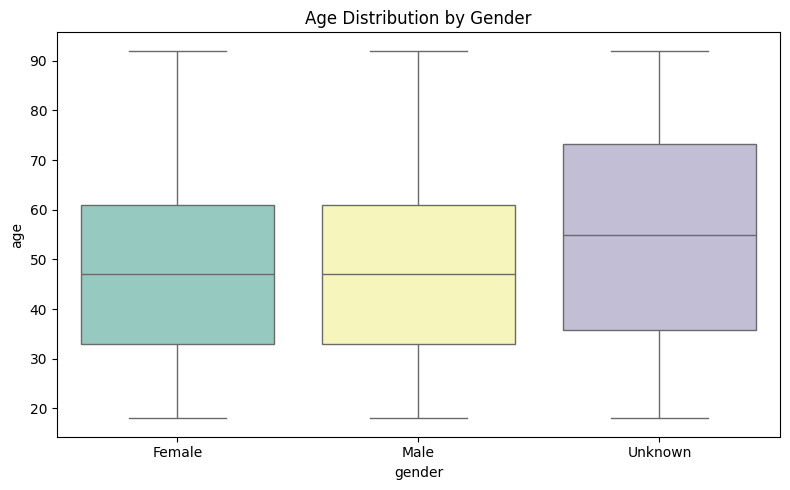

In [140]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='gender', y='age', palette='Set3')
plt.title('Age Distribution by Gender')
plt.tight_layout()
plt.show()

In [141]:
feature_3_insights = """
Age distribution is balanced across genders with similar medians for male and female. The 'unknown' category exhibits a wider interquartile range (IQR) and overall spread
which could be due to a smaller sample size or missing/incomplete data causing a less consistent distribution.
"""

In [142]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

###B.7 Explore 'Has Childer by Marital Status'

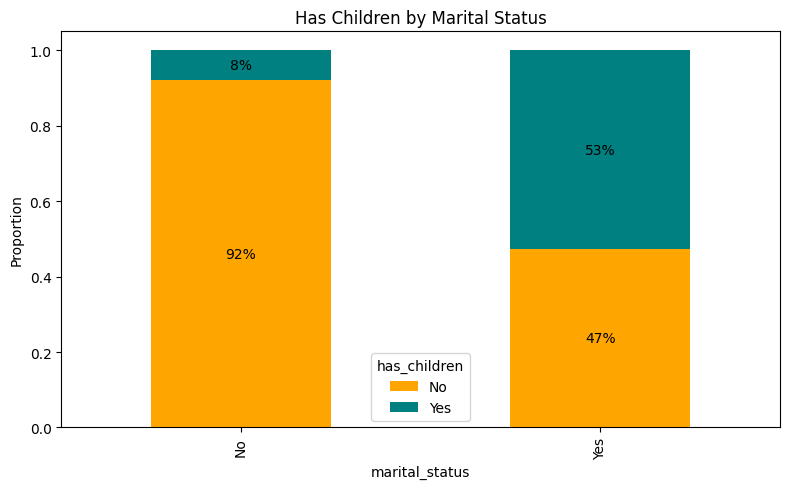

In [143]:
ct = pd.crosstab(df['marital_status'], df['has_children'], normalize='index')
colors = ['orange', 'teal']
ax = ct.plot(kind='bar', stacked=True, figsize=(8, 5), color=colors)
plt.title('Has Children by Marital Status')
plt.ylabel('Proportion')
plt.tight_layout()

for bars in ax.containers:
    ax.bar_label(
        bars,
        labels=[f'{h*100:.0f}%' if h > 0 else '' for h in bars.datavalues],
        label_type='center',
        fontsize=10,
        color='black'
    )

plt.show()


In [144]:
feature_4_insights = """
From the above distribution, as expected, married customers are more likely to have children. However, nearly half of married individuals don't have children, indicating
that marital status alone is not enough to be a perfect predictor.
"""

In [145]:
# Do not modify this code
print_tile(size="h3", key='feature_4_insights', value=feature_4_insights)

---
## C. Data Cleaning

### C.1 Copy Dataset

In [146]:
# Do not modify this code
df_clean = df.copy()
try:
  df_clean = df.copy()
except Exception as e:
  print(e)

### C.2 Fixing "Null Values"

In [147]:
# <Student to fill this section>
df_clean = df_clean.drop(['Gender', 'profile', 'locale', 'prefix', 'first_name', 'last_name', 'secondary_address', 'building_number', 'street_name', 'street_suffix', 'city', 'postcode', 'state_abbr', 'address', 'cc_number', 'cc_expiry', 'cc_security_code', 'company_name', 'company_suffix', 'user_agent'], axis=1)

df_clean.head()

,Unnamed: 0,customer_id,full_name,gender,dob,age,is_young_adult,is_senior,birth_country,passport_number,passport_expiry,phone_number,email,marital_status,has_children,number_dependents
0,0,9acb3a1e-a040-4280-887b-ef33381c7a16,Alexa Chung,Female,1974-10-10,50,No,No,AU,131053534,2029-11-21,2948.0872,jamespeterson@example.com,Yes,Yes,2
1,1,45360147-4c3e-4f3d-8d8d-a6aa8f0bb47f,Mrs. Megan,Female,1981-09-27,43,No,No,AU,379521345,2028-04-11,02-2279-7525,karenhester@example.net,Yes,No,0
2,2,8345bdc5-75fd-41da-8ce5-7828e5a27666,Amy Rose,Female,1989-09-16,35,No,No,PH,794022868,2028-12-13,(02).1955.3942,rrios@example.com,Yes,No,0
3,3,0ec226b1-22e6-4b98-919f-c1c0cd183ea7,Ryan Peterson,Male,2001-02-03,24,Yes,No,AU,M21113240,2027-05-23,03-6513-0081,collinmitchell@example.net,No,No,0
4,4,f588a5e1-7b36-4db2-af9a-2c14e041fccb,Shelby Meyer,Female,1977-02-11,48,No,No,AU,956682468,2029-10-24,+61.491.188.373,tammy90@example.com,No,No,0


In [148]:
#Removing unique value features
df_clean = df_clean.drop(['customer_id','Unnamed: 0'], axis=1)

In [149]:
df_clean.shape

(11688, 14)

In [150]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11688 entries, 0 to 11687
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   full_name          11688 non-null  object
 1   gender             11688 non-null  object
 2   dob                11688 non-null  object
 3   age                11688 non-null  int64 
 4   is_young_adult     11688 non-null  object
 5   is_senior          11688 non-null  object
 6   birth_country      11688 non-null  object
 7   passport_number    11688 non-null  object
 8   passport_expiry    11688 non-null  object
 9   phone_number       11688 non-null  object
 10  email              11688 non-null  object
 11  marital_status     11688 non-null  object
 12  has_children       11688 non-null  object
 13  number_dependents  11688 non-null  int64 
dtypes: int64(2), object(12)
memory usage: 1.2+ MB


In [151]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Removed features which had approximately 86% missing values, as their high level of sparsity limited their usefulness and could introduce noise or bias in the analysis.
Imputation was not considered viable for these features due to the high proportion of missing data and nature of the fields such as address details or credit card
information, which would have made any imputed values unreliable or misleading.
Removed 'customer_id' and 'Unnamed: 0' as they were unique identifiers and not relevant for modeling.
"""

In [152]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### C.3 Fixing "Duplicate Values"

In [153]:
# <Student to fill this section>
df_clean.duplicated().sum()

np.int64(2958)

In [154]:
df_clean.drop_duplicates(inplace=True)

df_clean.shape

(8730, 14)

In [155]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Removed duplicates because they do not add new information and can lead to data leakage, bias model training or inflate the significance of certain patterns. After
excluding unique identifiers (like customer ID), duplicate rows represent repeated customer profiles that can distort statistical distributions and model performance.
Removing them ensures the dataset reflects unique customer records and improves the integrity of analysis and modeling.
"""

In [156]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### C.4 Dropping Irrelevant Columns

In [157]:
# <Student to fill this section>
df_clean = df_clean.drop(['full_name', 'dob', 'passport_number', 'phone_number', 'email'], axis=1)

In [158]:
# <Student to fill this section>
data_cleaning_3_explanations = """
By removing personally identifiable information (PII) and non-contributing features such as full_name, email, phone_number and passport_number, we ensure that the dataset
is optimized for machine learning model training and free from noise. These attributes do not have a direct influence on model training and may introduce unnecessary
complexity or ethical concerns if included in a predictive model.
"""

In [159]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## D. Feature Engineering

### D.1 Copy Datasets

In [160]:
# Do not modify this code
try:
  df_eng = df_clean.copy()
except Exception as e:
  print(e)

### D.2 New Feature "age_group"



In [161]:
# <Student to fill this section>
df_eng.head()

,gender,age,is_young_adult,is_senior,birth_country,passport_expiry,marital_status,has_children,number_dependents
0,Female,50,No,No,AU,2029-11-21,Yes,Yes,2
1,Female,43,No,No,AU,2028-04-11,Yes,No,0
2,Female,35,No,No,PH,2028-12-13,Yes,No,0
3,Male,24,Yes,No,AU,2027-05-23,No,No,0
4,Female,48,No,No,AU,2029-10-24,No,No,0


In [162]:
# First, create age groups
bins = [0, 18, 30, 45, 60, 100]
labels = ['<18', '18–30', '31–45', '46–60', '60+']
df_eng['age_group'] = pd.cut(df_eng['age'], bins=bins, labels=labels, right=False)

In [163]:
df_eng['age_group'].value_counts()

,count
age_group,
60+,2563
31–45,2275
46–60,2227
18–30,1665
<18,0


In [164]:
# <Student to fill this section>
feature_engineering_1_explanations = """
Performed binning on 'age' to create 'age_group' to simplify analysis and capture nonlinear age-related patterns in modeling, while also enabling better segmentation and
interpretability of customer behavior across different life stages.
"""

In [165]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### D.3 New Feature "passport_status"



In [166]:
today = pd.Timestamp.today()
df_eng['passport_expiry'] = pd.to_datetime(df_eng['passport_expiry'])
df_eng['passport_status'] = pd.cut((df_eng['passport_expiry'] - today).dt.days,
                               bins=[-float('inf'), 0, 180, float('inf')],
                               labels=['Expired', 'Expiring Soon', 'Valid'])

In [167]:
df_eng['passport_status'].value_counts()

,count
passport_status,
Valid,7461
Expiring Soon,851
Expired,418


In [168]:
df_eng.head()

,gender,age,is_young_adult,is_senior,birth_country,passport_expiry,marital_status,has_children,number_dependents,age_group,passport_status
0,Female,50,No,No,AU,2029-11-21,Yes,Yes,2,46–60,Valid
1,Female,43,No,No,AU,2028-04-11,Yes,No,0,31–45,Valid
2,Female,35,No,No,PH,2028-12-13,Yes,No,0,31–45,Valid
3,Male,24,Yes,No,AU,2027-05-23,No,No,0,18–30,Valid
4,Female,48,No,No,AU,2029-10-24,No,No,0,46–60,Valid


In [169]:
# <Student to fill this section>
feature_engineering_2_explanations = """
A new categorical feature 'passport_status' was created by calculating the difference in days from the current date. The feature was binned into three meaningful categories:

1. 'Expired' – Passports with an expiry date in the past.
2. 'Expiring Soon' – Passports that will expire within the next 180 days.
3. 'Valid' – Passports that are valid for more than 180 days from today.

This was done to add temporal awareness to the dataset regarding document validity, enable risk-based segmentation and enhanced interpretability. This also might improve
modeling by reducing complexity and allowing categorical encoding instead of dealing with raw dates or time deltas directly.
"""

In [170]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

---
## E. Save Datasets

In [171]:
# <Student to fill this section>

In [172]:
try:
  df_eng.to_csv(folder_path / 'eda_customer_details.csv', index=False)
except Exception as e:
  print(e)